In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('dataset.csv')
df.head()

,Date,WSR0,WSR1,WSR2,WSR3,WSR4,WSR5,WSR6,WSR7,WSR8,...,RH50,U50,V50,HT50,KI,TT,SLP,SLP_,Precp,Result
0,1/1/1998,0.8,1.8,2.4,2.1,2,2.1,1.5,1.7,1.9,...,0.15,10.67,-1.56,5795,-12.1,17.9,10330,-55,0,0
1,1/2/1998,2.8,3.2,3.3,2.7,3.3,3.2,2.9,2.8,3.1,...,0.48,8.39,3.84,5805,14.05,29,10275,-55,0,0
2,1/3/1998,2.9,2.8,2.6,2.1,2.2,2.5,2.5,2.7,2.2,...,0.6,6.94,9.8,5790,17.9,41.3,10235,-40,0,0
3,1/4/1998,4.7,3.8,3.7,3.8,2.9,3.1,2.8,2.5,2.4,...,0.49,8.73,10.54,5775,31.15,51.7,10195,-40,2.08,0
4,1/5/1998,2.6,2.1,1.6,1.4,0.9,1.5,1.2,1.4,1.3,...,?,?,?,?,?,?,?,?,0.58,0


In [3]:
df.drop(columns='Date', inplace=True)
df.head()


,WSR0,WSR1,WSR2,WSR3,WSR4,WSR5,WSR6,WSR7,WSR8,WSR9,...,RH50,U50,V50,HT50,KI,TT,SLP,SLP_,Precp,Result
0,0.8,1.8,2.4,2.1,2,2.1,1.5,1.7,1.9,2.3,...,0.15,10.67,-1.56,5795,-12.1,17.9,10330,-55,0,0
1,2.8,3.2,3.3,2.7,3.3,3.2,2.9,2.8,3.1,3.4,...,0.48,8.39,3.84,5805,14.05,29,10275,-55,0,0
2,2.9,2.8,2.6,2.1,2.2,2.5,2.5,2.7,2.2,2.5,...,0.6,6.94,9.8,5790,17.9,41.3,10235,-40,0,0
3,4.7,3.8,3.7,3.8,2.9,3.1,2.8,2.5,2.4,3.1,...,0.49,8.73,10.54,5775,31.15,51.7,10195,-40,2.08,0
4,2.6,2.1,1.6,1.4,0.9,1.5,1.2,1.4,1.3,1.4,...,?,?,?,?,?,?,?,?,0.58,0


In [4]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

for col in df.columns:
    if col != 'Date':
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [5]:
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 WSR0      299
WSR1      292
WSR2      294
WSR3      292
WSR4      293
         ... 
TT        125
SLP        95
SLP_      158
Precp       2
Result      0
Length: 73, dtype: int64


In [8]:
df = df.fillna(df.mean(numeric_only=True))
print("Cleaned data shape:", df.shape)


Cleaned data shape: (2534, 73)


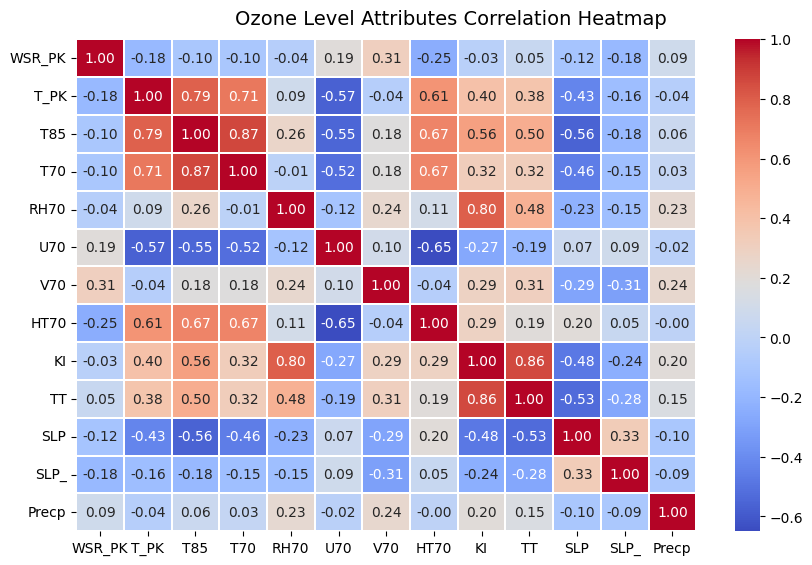

In [9]:

# Correlation Matrix Heatmap
f, ax = plt.subplots(figsize=(10, 6))
subset_attributes = ['WSR_PK','T_PK','T85','T70','RH70','U70','V70','HT70','KI','TT','SLP','SLP_','Precp']
corr = df[subset_attributes].corr()
hm = sns.heatmap(round(corr,2), annot=True, ax=ax, cmap="coolwarm",fmt='.2f',
                 linewidths=.05)
f.subplots_adjust(top=0.93)
t= f.suptitle('Ozone Level Attributes Correlation Heatmap', fontsize=14)

In [10]:
# Select only correlated features
X = df[['T85', 'T70', 'TT', 'KI', 'SLP']]
y = df['Result']

print("Selected Features shape:", X.shape)
print("Labels shape:", y.shape)


Selected Features shape: (2534, 5)
Labels shape: (2534,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (2027, 5)
Test shape: (507, 5)


In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [13]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000, random_state=42)

In [15]:
logreg.fit(X_train_scaled, y_train)

y_pred_logreg = logreg.predict(X_test_scaled)


In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

logreg_acc = accuracy_score(y_test, y_pred_logreg)
print(f"Logistic Regression Accuracy: {logreg_acc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_logreg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_logreg))


Logistic Regression Accuracy: 0.9369

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97       475
           1       0.00      0.00      0.00        32

    accuracy                           0.94       507
   macro avg       0.47      0.50      0.48       507
weighted avg       0.88      0.94      0.91       507

Confusion Matrix:
 [[475   0]
 [ 32   0]]


C:\Users\adity\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\adity\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\adity\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

In [17]:
from sklearn import svm

clf = svm.SVC(kernel='linear') 
clf.fit(X_train, y_train)

Y_pred = clf.predict(X_test)

In [18]:
from sklearn import metrics
print("\nClassification Report:\n", classification_report(y_test, Y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, Y_pred))
print("Accuracy:", metrics.accuracy_score(y_test, Y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97       475
           1       0.00      0.00      0.00        32

    accuracy                           0.94       507
   macro avg       0.47      0.50      0.48       507
weighted avg       0.88      0.94      0.91       507

Confusion Matrix:
 [[475   0]
 [ 32   0]]
Accuracy: 0.9368836291913215


C:\Users\adity\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\adity\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\adity\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

In [19]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

Y_pred = knn.predict(X_test)

In [20]:
print("\nClassification Report:\n", classification_report(y_test, Y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, Y_pred))
print("Accuracy:",metrics.accuracy_score(y_test, Y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.99      0.96       475
           1       0.00      0.00      0.00        32

    accuracy                           0.93       507
   macro avg       0.47      0.50      0.48       507
weighted avg       0.88      0.93      0.90       507

Confusion Matrix:
 [[472   3]
 [ 32   0]]
Accuracy: 0.9309664694280079


In [21]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

In [22]:
xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)

c:\Users\adity\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [19:59:57] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [23]:
xgb_acc = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {xgb_acc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9369

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97       475
           1       0.50      0.03      0.06        32

    accuracy                           0.94       507
   macro avg       0.72      0.51      0.51       507
weighted avg       0.91      0.94      0.91       507

Confusion Matrix:
 [[474   1]
 [ 31   1]]


In [25]:
from collections import Counter
from imblearn.over_sampling import SMOTE

print("Before SMOTE:", Counter(y))

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("After SMOTE:", Counter(y_resampled))


Before SMOTE: Counter({0: 2374, 1: 160})
After SMOTE: Counter({0: 2374, 1: 2374})


In [29]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_resampled, y_resampled)

y_pred_xgb = xgb_model.predict(X)

print("XGBoost Accuracy:", accuracy_score(y, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y, y_pred_xgb))


XGBoost Accuracy: 0.9917127071823204

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00      2374
           1       0.92      0.95      0.94       160

    accuracy                           0.99      2534
   macro avg       0.96      0.97      0.97      2534
weighted avg       0.99      0.99      0.99      2534


Confusion Matrix:
 [[2361   13]
 [   8  152]]


In [32]:
import pickle

# Save the trained XGBoost model
with open("xgb_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)
